# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


In [2]:
# Your code here :
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Plot 10 random images from each class
plt.figure(figsize=(15, 15))

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

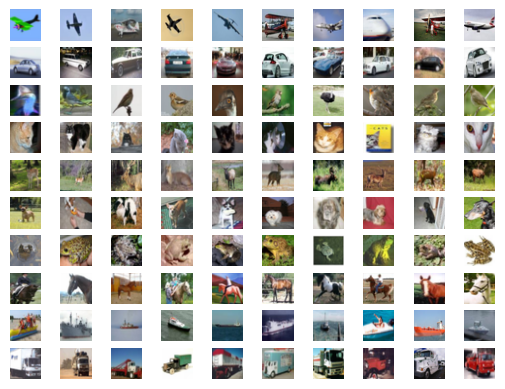

In [3]:
for class_id in range(10):
    indices = np.where(y_train.flatten() == class_id)[0]
    random_indices = np.random.choice(indices, 10, replace=False)

    for j, idx in enumerate(random_indices):
        plt.subplot(10, 10, class_id * 10 + j + 1)
        plt.imshow(x_train[idx])
        plt.axis('off')

plt.show()

In [4]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [6]:
from keras.backend import clear_session
clear_session()

In [7]:
# Your code here :
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [8]:
# Your code here :
from keras.optimizers import SGD

model.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.1583 - loss: 2.2537 - val_accuracy: 0.2180 - val_loss: 2.1983
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.2379 - loss: 2.1380 - val_accuracy: 0.2664 - val_loss: 2.0776
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.2839 - loss: 2.0333 - val_accuracy: 0.2965 - val_loss: 1.9926
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.3150 - loss: 1.9595 - val_accuracy: 0.3226 - val_loss: 1.9353
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.3346 - loss: 1.9104 - val_accuracy: 0.3378 - val_loss: 1.8881
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.3467 - loss: 1.8745 - val_accuracy: 0.3514 - val_loss: 1.8549
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3590 - loss: 1.8445 - val_accuracy: 0.3438 - val_loss: 1.8564
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.3662 - loss: 1.8210 - val_accuracy: 0.3742

*   Plot the cross entropy loss curve and the accuracy curve

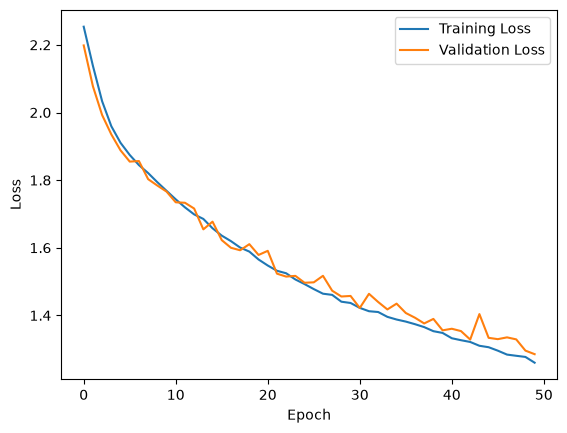

In [9]:
# Your code here :
import matplotlib.pyplot as plt

# Loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

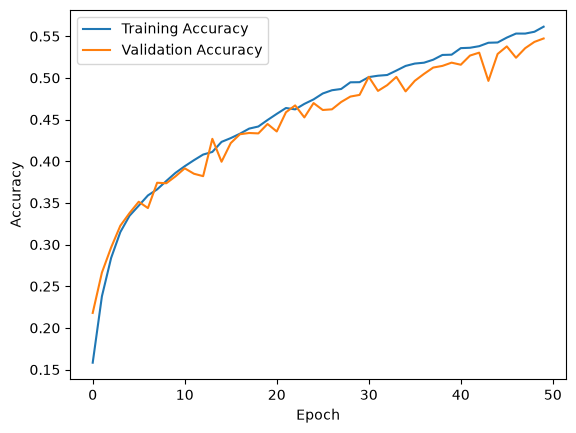

In [10]:
# Accuracy curve
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [9]:
from keras.backend import clear_session
clear_session()

In [11]:
# Your code here :
vgg_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [12]:
# Your code here :
vgg_model.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 298ms/step - accuracy: 0.1898 - loss: 2.2328 - val_accuracy: 0.2259 - val_loss: 2.1495
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 358ms/step - accuracy: 0.2641 - loss: 2.0779 - val_accuracy: 0.2883 - val_loss: 2.0088
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 352ms/step - accuracy: 0.2964 - loss: 1.9831 - val_accuracy: 0.2983 - val_loss: 1.9625
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 367ms/step - accuracy: 0.3291 - loss: 1.9065 - val_accuracy: 0.3361 - val_loss: 1.8824
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 350ms/step - accuracy: 0.3500 - loss: 1.8518 - val_accuracy: 0.3725 - val_loss: 1.8024
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.3652 - loss: 1.8114 - val_accuracy: 0.3680 - val_loss: 1.7859
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.3767 - loss: 1.7726 - val_accuracy: 0.3646 - val_loss: 1.7754
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 303ms/step - accuracy: 0.3862 - loss: 1.7473 - val_accu

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

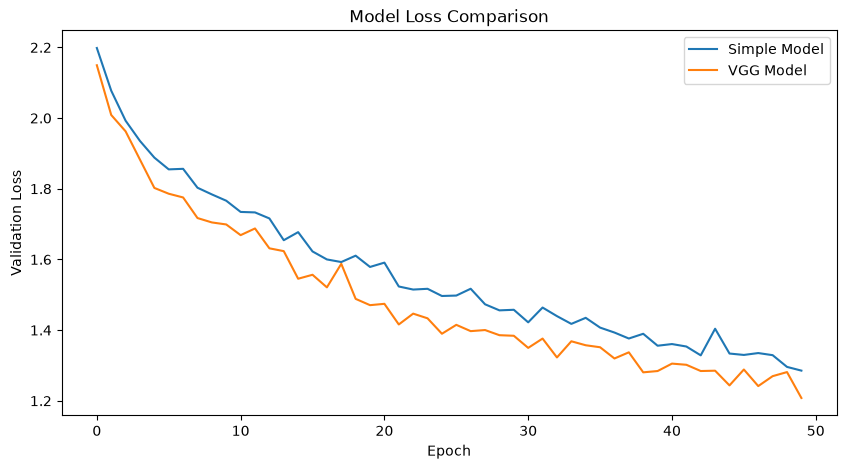

In [13]:
# Your code here :
plt.figure(figsize=(10, 5))

plt.plot(history.history['val_loss'], label='Simple Model')
plt.plot(history_vgg.history['val_loss'], label='VGG Model')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Model Loss Comparison')
plt.legend()
plt.show()

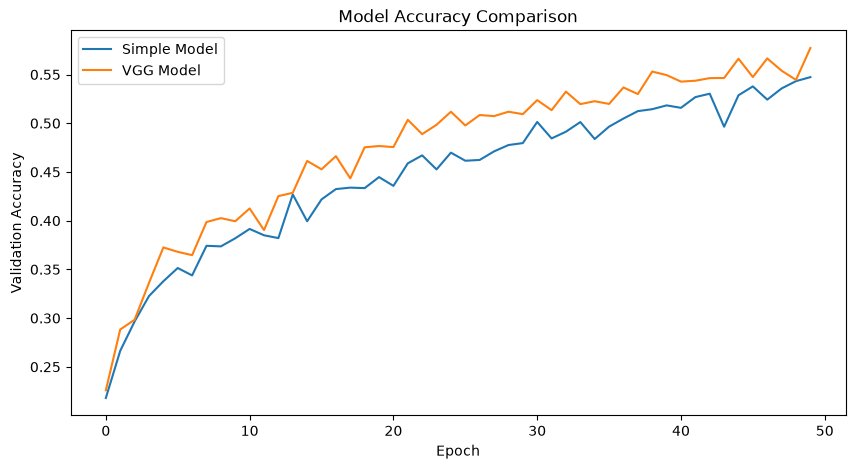

In [14]:
# Compare Accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history['val_accuracy'], label='Simple Model')
plt.plot(history_vgg.history['val_accuracy'], label='VGG Model')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.show()

**Comment on the observation**

*(Double-click or enter to edit)*

The deeper VGG model performs better than the simple CNN. It has lower validation loss and higher validation accuracy. This shows that the additional convolutional layer helps the model learn more useful image features.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [16]:
# Your code here :
from sklearn.metrics import confusion_matrix
# Predict test data
y_pred_prob = vgg_model.predict(x_test)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded y_test back to class numbers
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

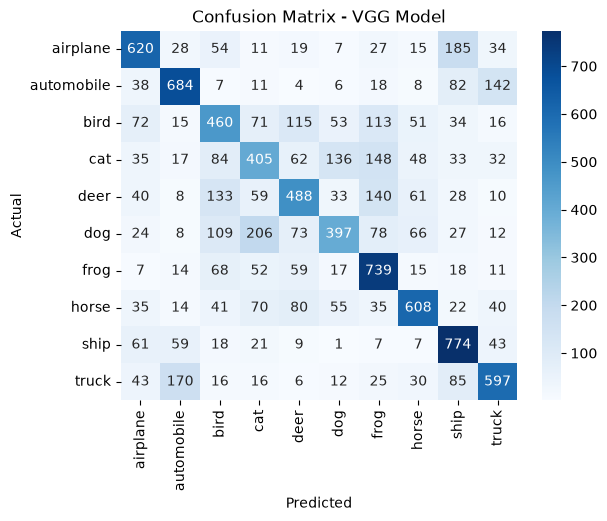

In [18]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - VGG Model')
plt.show()

**Comment here :**

*(Double-click or enter to edit)*
The model performs better on classes such as ship and frog. It has more difficulty distinguishing visually similar classes. For example, cats are often confused with dogs and frogs, automobiles with trucks, and airplanes with ships. Overall, most correct predictions appear on the diagonal, but there are still several class confusions.

*    Print the test accuracy for the trained model.

In [19]:
# Your code here :
loss, accuracy = vgg_model.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.5771999955177307
Test Accuracy (%): 57.71999955177307


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [20]:


vgg_complete = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Classifier
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

vgg_complete.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [22]:

import tensorflow as tf
# Resize images from 32x32 to 64x64 while loading batches
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(5000)
train_ds = train_ds.batch(512)
train_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, (64, 64)), y)
)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(512)
test_ds = test_ds.map(
    lambda x, y: (tf.image.resize(x, (64, 64)), y)
)

# Compile
vgg_complete.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

# Train for 10 epochs
history_complete = vgg_complete.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

# Predict test data
y_pred_prob = vgg_complete.predict(test_ds)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Complete VGG Model')
plt.show()

Epoch 1/10


c:\Users\rayha\Desktop\ironhack\01_python\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


98/98 ━━━━━━━━━━━━━━━━━━━━ 2804s 29s/step - accuracy: 0.1152 - loss: 2.2989 - val_accuracy: 0.1442 - val_loss: 2.2939
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2767s 28s/step - accuracy: 0.1612 - loss: 2.2826 - val_accuracy: 0.1907 - val_loss: 2.2608
Epoch 3/10
 2/98 ━━━━━━━━━━━━━━━━━━━━ 22:40 14s/step - accuracy: 0.1943 - loss: 2.2563

KeyboardInterrupt: 

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:



Adds non-linearity and helps neurons decide what output to pass.

2 - Key Differences between sigmoid and softmax:



Sigmoid is mainly for binary output; Softmax is for multiple classes.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:


Categorical is for multi-class classification; Binary is for two classes.
